In [2]:
import pandas as pd
import numpy as np
import kagglehub
import os

/opt/homebrew/Caskroom/miniforge/base/envs/houseprice/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
df_fe = pd.read_csv("../data/feature_engineered.csv")
df_fe.shape

(2930, 90)

In [5]:
y = df_fe["SalePrice"]
X = df_fe.drop(columns=["SalePrice"])

In [6]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 89 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   str    
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   str    
 7   Alley            198 non-null    str    
 8   Lot Shape        2930 non-null   str    
 9   Land Contour     2930 non-null   str    
 10  Utilities        2930 non-null   str    
 11  Lot Config       2930 non-null   str    
 12  Land Slope       2930 non-null   str    
 13  Neighborhood     2930 non-null   str    
 14  Condition 1      2930 non-null   str    
 15  Condition 2      2930 non-null   str    
 16  Bldg Type        2930 non-null   str    
 17  House Style      2930 non

In [9]:
X = pd.get_dummies(X)

In [7]:
X.isnull().sum().sort_values(
    ascending=False
).head(20)

Pool QC           2917
Misc Feature      2824
Alley             2732
Fence             2358
Mas Vnr Type      1775
Fireplace Qu      1422
Lot Frontage       490
Garage Qual        159
Garage Cond        159
Garage Yr Blt      159
Garage Finish      159
Garage Type        157
Bsmt Exposure       83
BsmtFin Type 2      81
Bsmt Qual           80
Bsmt Cond           80
BsmtFin Type 1      80
Mas Vnr Area        23
Total Bath           2
Bsmt Half Bath       2
dtype: int64

In [8]:
X = X.fillna(
    X.median(numeric_only=True)
)

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [12]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(
    X_train,
    y_train
)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](313,)","[ 1.05,-0. ,-0.48,...,-0. ,-0. , 0.01]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](313,)","['Order','PID','MS SubClass',...,'Sale Condition_Family', 'Sale Condition_Normal','Sale Condition_Partial']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,7.179e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,313
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,9


In [13]:
pred = model.predict(
    X_test
)

In [14]:
from sklearn.metrics import mean_squared_error

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        pred
    )
)

print(rmse)

37935.33937248374


In [15]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

rmse = np.sqrt(mean_squared_error(y_test, pred))
mae = mean_absolute_error(y_test, pred)
r2 = r2_score(y_test, pred)

print("RMSE =", rmse)
print("MAE =", mae)
print("R² =", r2)

RMSE = 37935.33937248374
MAE = 21688.035529802295
R² = 0.8205074686541252


In [16]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

In [17]:
rmse_rf = np.sqrt(
    mean_squared_error(y_test, pred_rf)
)

mae_rf = mean_absolute_error(y_test, pred_rf)

r2_rf = r2_score(y_test, pred_rf)

print(rmse_rf)
print(mae_rf)
print(r2_rf)

24530.31946503834
14842.23162116041
0.9249475552572457


In [18]:
importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
)

importance = importance.sort_values(
    ascending=False
)

importance.head(20)

Quality_Area      0.650985
Overall Qual      0.061372
Total Area        0.042800
BsmtFin SF 1      0.023961
Total Bsmt SF     0.020616
Bsmt Qual_Ex      0.015946
House Age         0.014953
Year Built        0.013591
2nd Flr SF        0.012225
Lot Area          0.012064
Garage Cars       0.008579
Garage Area       0.008517
1st Flr SF        0.007688
PID               0.006534
Year Remod/Add    0.005555
Bsmt Unf SF       0.004350
Gr Liv Area       0.003881
Garage Yr Blt     0.003851
Lot Frontage      0.003714
Open Porch SF     0.003176
dtype: float64

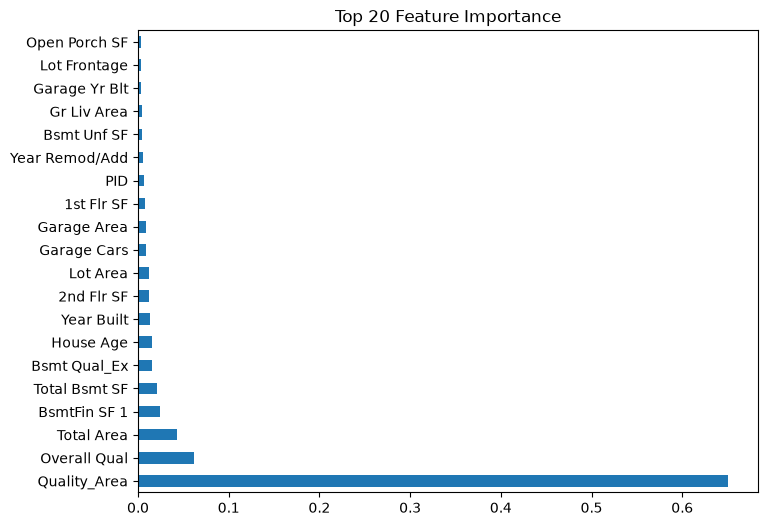

In [20]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))

importance.head(20).plot(kind="barh")

plt.title("Top 20 Feature Importance")

plt.show()